# Clinical Risk Prediction for Heart Disease
## Model Evaluation

This notebook evaluates the **reduced logistic regression model** selected in `03_logistic_regression_model.ipynb` via backward AIC elimination.

### Selected model (from 03_logistic_regression_model)
| Feature | Transformation |
|-----|-----|
| `age` | StandardScaler |
| `ejection_fraction` | StandardScaler |
| `high_blood_pressure` | None (binary, pass-through) |
| `serum_creatinine` | log1p then StandardScaler |

`time` is **excluded** from all models: it is a follow-up variable known only at the end of the observation period, not at admission. Including it is data leakage.

### Evaluation plan
1. Reconstruct the same stratified split (same seed as 03_logistic_regression_model)
2. Build sklearn pipelines with correct preprocessing per feature group
3. Select decision threshold via cross-validation on training data, not on the test set
4. Evaluate on the held-out test set with bootstrap 95% CIs
5. ROC and Precision-Recall curves
6. Calibration: visual curve + Hosmer-Lemeshow test
7. Decision Curve Analysis (clinical net benefit)
8. Persist the final model artifact

### Note on sklearn vs statsmodels
03_logistic_regression_model uses `statsmodels.Logit` (no regularisation) for inference and odds ratio interpretation.  
This notebook uses `sklearn.LogisticRegression` (L2, C=1.0 by default) for pipeline compatibility.  
Both fit logistic regression but produce slightly different coefficients due to regularisation.  
For coefficient interpretation and ORs, refer to 03_logistic_regression_model. For discrimination and calibration, use this notebook.

## Table of Contents

1. [Data Loading and Setup](#1-data-loading-and-setup)
2. [Preprocessing Pipeline](#2-preprocessing-pipeline)
3. [Threshold Selection via Cross-Validation](#3-threshold-selection-via-cross-validation)
4. [Test Set Evaluation](#4-test-set-evaluation)
5. [ROC and Precision-Recall Curves](#5-roc-and-precision-recall-curves)
6. [Calibration](#6-calibration)
7. [Decision Curve Analysis](#7-decision-curve-analysis)
8. [Model Persistence](#8-model-persistence)
9. [Summary](#9-summary)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import random
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from scipy.stats import gaussian_kde
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix as conf_mat

sys.path.append(str(Path.cwd().parent / 'src'))
from clinical_risk.train_eval import (
    evaluate_at_threshold,
    hosmer_lemeshow_test,
    compute_dca,
    bootstrap_ci,
    cv_optimal_threshold,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

seed = 891
random.seed(seed)
np.random.seed(seed)

## 1. Data Loading and Setup

In [3]:
data = fetch_ucirepo(id=519)
X = data.data.features.copy()
y = data.data.targets.squeeze().copy()

# Exclude time: known only at end of follow-up period — data leakage
X = X.drop(columns=['time'])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=seed
)

print(f'Train : {X_train.shape} | event rate : {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}  | event rate : {y_test.mean():.3f}')

Train : (239, 11) | event rate : 0.322
Test  : (60, 11)  | event rate : 0.317


## 2. Preprocessing Pipeline

The reduced model selected by backward AIC in 03_logistic_regression_model retains four predictors:
`age`, `ejection_fraction`, `high_blood_pressure`, `serum_creatinine`.

`serum_creatinine` was highly skewed (skew = 4.46) and was log1p-transformed before fitting in 03_logistic_regression_model.
Here the transformation is embedded inside the sklearn pipeline using `FunctionTransformer` so it is
applied consistently during cross-validation and test-set inference with no risk of leakage.

**Feature treatment by group**

| Feature | Group | Pipeline step |
|-----|-----|-----|
| `age`, `ejection_fraction` | Continuous | StandardScaler |
| `serum_creatinine` | Skewed continuous | log1p then StandardScaler |
| `high_blood_pressure` | Binary flag | Pass-through (no scaling) |

`ColumnTransformer` applies each transformation only to its assigned columns.
The full model uses StandardScaler on all continuous features and pass-through for binary flags,
with no log transform (consistent with the 03_logistic_regression_model full model specification).

In [4]:
# Feature groups
reduced_scale_vars  = ['age', 'ejection_fraction']
reduced_log_vars    = ['serum_creatinine']
reduced_binary_vars = ['high_blood_pressure']
reduced_raw_vars    = reduced_scale_vars + reduced_log_vars + reduced_binary_vars

binary_cols  = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
numeric_full = [c for c in X_train.columns if c not in binary_cols]
full_raw_vars = X_train.columns.tolist()  # all 11 features (time already excluded)

# Preprocessing for reduced model 
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ('scale',       StandardScaler(),
                        reduced_scale_vars),
        ('log_scale',   Pipeline([('log',   FunctionTransformer(np.log1p)),
                                  ('scale', StandardScaler())]),
                        reduced_log_vars),
        ('passthrough', 'passthrough',
                        reduced_binary_vars),
    ],
    remainder='drop',
)

#  Preprocessing for full model 
full_preprocessor = ColumnTransformer(
    transformers=[
        ('scale',       StandardScaler(), numeric_full),
        ('passthrough', 'passthrough',    binary_cols),
    ],
    remainder='drop',
)

#  Final pipelines 
reduced_pipeline = Pipeline([
    ('prep',  reduced_preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=seed)),
])

full_pipeline = Pipeline([
    ('prep',  full_preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=seed)),
])

#  Fit 
reduced_pipeline.fit(X_train[reduced_raw_vars], y_train)
full_pipeline.fit(X_train[full_raw_vars],    y_train)

print('Reduced pipeline features :', reduced_raw_vars)
print('Full pipeline features     :', full_raw_vars)

Reduced pipeline features : ['age', 'ejection_fraction', 'serum_creatinine', 'high_blood_pressure']
Full pipeline features     : ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


### Evaluation vs explicability: Model

In 03_logistic_regression_model, statsmodels is used for interpretation (odds ratios, p-values, AIC), while scikit-learn is used for evaluation and model delivery (pipelines, cross-validation, and deployment-ready workflows).

Logistic Regression (L2, C=1)
- Reduces overfitting by shrinking coefficients
- Improves generalization on unseen data
- Retains all features (unlike L1, which can eliminate them)
- More stable when features are correlated
- Strong default baseline without the need for tuning


## 3. Threshold Selection via Cross-Validation

The default classification threshold of 0.5 is arbitrary and poorly suited for a 32% event rate.
Optimising it is necessary.

**Why threshold = 0.5 fails with a 32% event rate?**

- A threshold of 0.5 implies that a patient is classified as high-risk only when the model predicts a probability of death greater than 50%.
- Base rate (population average): This model is trained on data where 32% of patients die. It learns that an average patient has a 32% chance of dying

### **Example:**
Model-predicted probability for a specific patient(example): 40% (0.40)         
Relative risk = patient probability / base rate = 0.40 / 0.32 = **1.25**

This means the patient has a **1.25× higher risk than average**. In other words, **25% higher than the typical patient**

| Measure       | Calculation | Result                             |
| ------------- | ----------- | ---------------------------------- |
| Relative risk | 0.40 / 0.32 | 1.25 → 25% above average           |
| Absolute risk | 0.40 − 0.32 | +8 percentage points above average |


A patient with P = 0.40 is not average — they are clearly above the population baseline (0.32). However, a 0.5 threshold would still classify this patient as low-risk, effectively ignoring this elevated risk.


###  **Procedure:**
1. Run stratified 5-fold CV on the training set
2. In each fold: fit the reduced pipeline on the training portion, predict probabilities on the held-out fold
3. Find the threshold that maximises Youden's J = sensitivity + specificity - 1
4. Average the five fold-optimal thresholds to obtain one CV-selected threshold
5. Apply this threshold exactly once to the test set.

In [5]:
fold_thresholds, cv_threshold = cv_optimal_threshold(
    X_train, y_train,
    pipeline=reduced_pipeline,
    features=reduced_raw_vars,
    n_splits=5,
    seed=seed,
)

print(f'Youden threshold per fold        : {fold_thresholds}')
print(f'CV-selected threshold (mean)     : {cv_threshold:.3f}')

Youden threshold per fold        : [0.4068, 0.4189, 0.2622, 0.3378, 0.3167]
CV-selected threshold (mean)     : 0.348


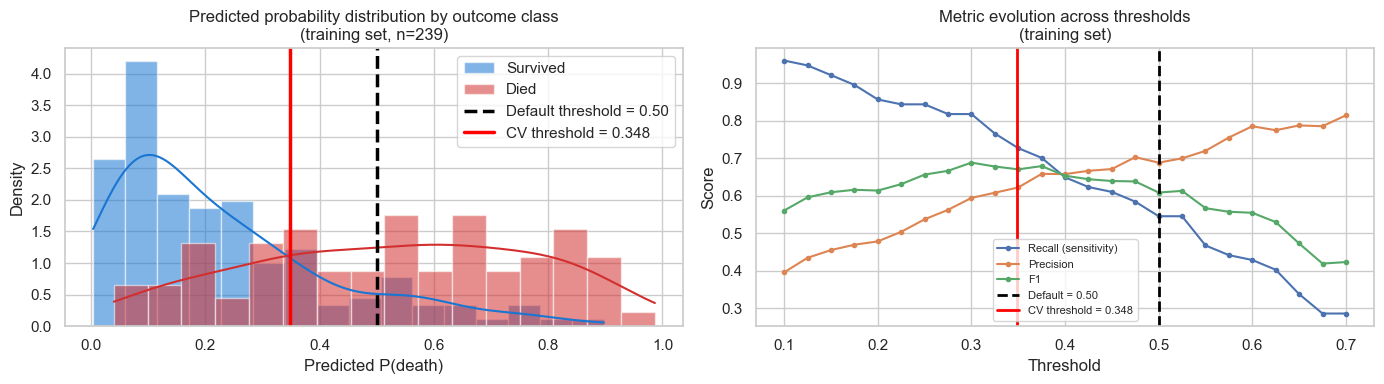

Total deaths in training set: 77

Threshold                     TP (caught)  FN (missed)  FP (false alarm)   Recall  Precision
---------------------------------------------------------------------------
Default (0.50)                         42           35                19    0.545      0.689
CV-selected (0.348)                    56           21                34    0.727      0.622


In [6]:
# Predictions on the training set (the test set is only touched once, in Section 4)
y_prob_train_demo = reduced_pipeline.predict_proba(X_train[reduced_raw_vars])[:, 1]
y_true_train_demo = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: distribution of predicted probabilities by true class ---
for val, label, color in [(0, 'Survived', '#1976D2'), (1, 'Died', '#D32F2F')]:
    probs_class = y_prob_train_demo[y_true_train_demo == val]
    axes[0].hist(probs_class, bins=16, alpha=0.55, color=color, label=label, density=True)

    kde = gaussian_kde(probs_class)
    x_vals = np.linspace(probs_class.min(), probs_class.max(), 200)
    axes[0].plot(x_vals, kde(x_vals), color=color)

axes[0].axvline(0.50,         color='black', linestyle='--', linewidth=2.5, label='Default threshold = 0.50')
axes[0].axvline(cv_threshold, color='red',   linestyle='-',  linewidth=2.5,
                label=f'CV threshold = {cv_threshold:.3f}')
axes[0].set_xlabel('Predicted P(death)')
axes[0].set_ylabel('Density')
axes[0].set_title('Predicted probability distribution by outcome class\n(training set, n=239)')
axes[0].legend()

# --- Right: metric curves across threshold range ---
thrs_range = np.arange(0.10, 0.71, 0.025)
recalls, precisions, f1s = [], [], []

for t in thrs_range:
    y_pred_t = (y_prob_train_demo >= t).astype(int)
    recalls.append(recall_score(y_true_train_demo,    y_pred_t, zero_division=0))
    precisions.append(precision_score(y_true_train_demo, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_true_train_demo,            y_pred_t, zero_division=0))

axes[1].plot(thrs_range, recalls,    marker='.', label='Recall (sensitivity)')
axes[1].plot(thrs_range, precisions, marker='.', label='Precision')
axes[1].plot(thrs_range, f1s,        marker='.', label='F1')
axes[1].axvline(0.50,         color='black', linestyle='--', linewidth=2, label='Default = 0.50')
axes[1].axvline(cv_threshold, color='red',   linestyle='-',  linewidth=2,
                label=f'CV threshold = {cv_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Metric evolution across thresholds\n(training set)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Summary: caught vs missed deaths at each threshold ---
n_deaths = int(y_true_train_demo.sum())
print(f'Total deaths in training set: {n_deaths}\n')
print(f'{"Threshold":<28} {"TP (caught)":>12} {"FN (missed)":>12} {"FP (false alarm)":>17} {"Recall":>8} {"Precision":>10}')
print('-' * 75)
for thr, label in [(0.50, 'Default (0.50)'), (cv_threshold, f'CV-selected ({cv_threshold:.3f})')]:
    y_pred_t = (y_prob_train_demo >= thr).astype(int)
    tn, fp, fn, tp = conf_mat(y_true_train_demo, y_pred_t).ravel()
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f'{label:<28} {tp:>12} {fn:>12} {fp:>17} {rec:>8.3f} {prec:>10.3f}')

## 4. Test Set Evaluation

The reduced pipeline is evaluated on the held-out test set (n=60, approximately 19 positive cases) using the threshold selected in Section 3. The threshold is applied once and not adjusted.

**Bootstrap 95% CIs**    
Test set: n = 60 patients, event rate ≈ 32% → ~19 true deaths in the test set.    
Recall = TP / (TP + FN) = TP / total positives    
With only 19 true positives, a single misclassified patient has this effect:   

| Situation               | TP | Recall            |
|------------------------|----|-------------------|
| Model catches 15 of 19 | 15 | 15/19 = 0.789     |
| Model catches 14 of 19 | 14 | 14/19 = 0.737     |
| Difference             |    | 0.052 ≈ 5 pp      |
General rule: with N positives, 1 patient = 1/N change in recall.

Here: 1/19 = 0.053 → ~5 percentage points per patient.


So, Point estimates without confidence intervals give a false sense of precision.

Threshold-dependent metrics (recall, precision, F1, specificity) are reported as point
estimates at the CV-selected threshold. The full confusion matrix is shown below.

In [7]:
#  Predictions on test set 
y_prob_reduced = reduced_pipeline.predict_proba(X_test[reduced_raw_vars])[:, 1]
y_prob_full    = full_pipeline.predict_proba(X_test[full_raw_vars])[:, 1]
y_true_arr     = y_test.values

#  Bootstrap 95% CIs for threshold-independent metrics 
ci_roc   = bootstrap_ci(y_true_arr, y_prob_reduced, roc_auc_score,          seed=seed)
ci_pr    = bootstrap_ci(y_true_arr, y_prob_reduced, average_precision_score, seed=seed)
ci_brier = bootstrap_ci(y_true_arr, y_prob_reduced, brier_score_loss,        seed=seed)

#  Threshold-dependent metrics at CV-selected threshold 
ev = evaluate_at_threshold(y_true_arr, y_prob_reduced, threshold=cv_threshold)

#  Summary table 
summary = pd.DataFrame([{
    'model'      : 'reduced (CV threshold)',
    'threshold'  : f'{cv_threshold:.3f}',
    'ROC-AUC'    : f"{roc_auc_score(y_true_arr, y_prob_reduced):.3f}  [{ci_roc[0]:.3f}-{ci_roc[1]:.3f}]",
    'AUC-PR'     : f"{average_precision_score(y_true_arr, y_prob_reduced):.3f}  [{ci_pr[0]:.3f}-{ci_pr[1]:.3f}]",
    'Brier'      : f"{brier_score_loss(y_true_arr, y_prob_reduced):.3f}  [{ci_brier[0]:.3f}-{ci_brier[1]:.3f}]",
    'Recall'     : f"{ev['recall']:.3f}",
    'Precision'  : f"{ev['precision']:.3f}",
    'F1'         : f"{ev['f1']:.3f}",
    'Specificity': f"{ev['specificity']:.3f}",
}])
summary

,model,threshold,ROC-AUC,AUC-PR,Brier,Recall,Precision,F1,Specificity
0,reduced (CV threshold),0.348,0.660 [0.490-0.804],0.542 [0.361-0.756],0.211 [0.151-0.282],0.579,0.478,0.524,0.707


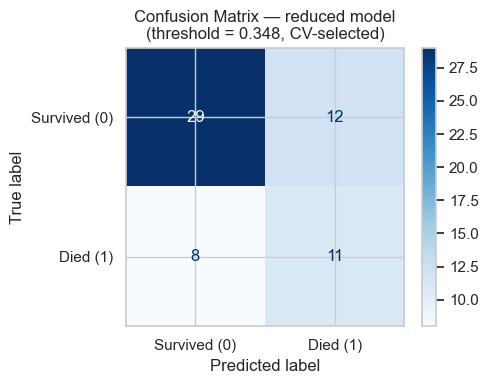

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true_arr,
    (y_prob_reduced >= cv_threshold).astype(int),
    display_labels=['Survived (0)', 'Died (1)'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Confusion Matrix — reduced model\n(threshold = {cv_threshold:.3f}, CV-selected)')
plt.tight_layout()
plt.show()

## 5. ROC and Precision-Recall Curves

Both curves compare the reduced model (4 features) against the full model (11 features).

**ROC-AUC** and **AUC-PR** will be used together since for the class imbalace dataset, which is the case, high performance on the majority class (survived) can inflate AUC without
improving detection of the minority class (death).

In this case, **AUC-PR** focuses on the positive class. With a 32% event rate, a no-skill classifier achieves AUC-PR approximately equal to the prevalence (0.32). All improvement above this line represents genuine minority-class detection. AUC-PR is the more clinically informative metric here.

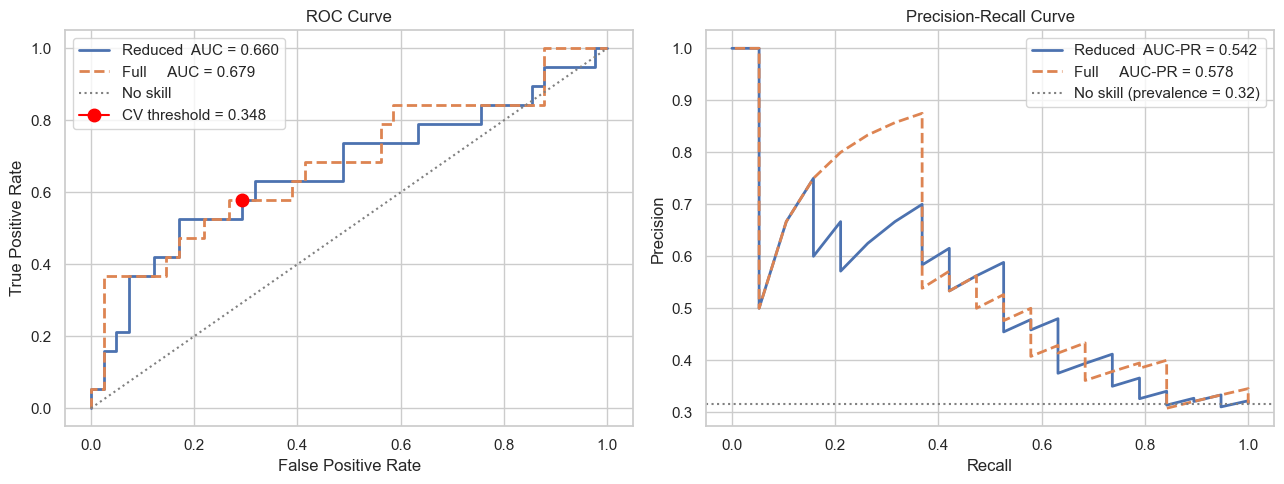

In [9]:
fpr_r, tpr_r, _  = roc_curve(y_true_arr, y_prob_reduced)
fpr_f, tpr_f, _  = roc_curve(y_true_arr, y_prob_full)
prec_r, rec_r, _ = precision_recall_curve(y_true_arr, y_prob_reduced)
prec_f, rec_f, _ = precision_recall_curve(y_true_arr, y_prob_full)

auc_r = roc_auc_score(y_true_arr, y_prob_reduced)
auc_f = roc_auc_score(y_true_arr, y_prob_full)
apr_r = average_precision_score(y_true_arr, y_prob_reduced)
apr_f = average_precision_score(y_true_arr, y_prob_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_r, tpr_r, label=f'Reduced  AUC = {auc_r:.3f}', linewidth=2)
axes[0].plot(fpr_f, tpr_f, label=f'Full     AUC = {auc_f:.3f}', linewidth=2, linestyle='--')
axes[0].plot([0, 1], [0, 1], linestyle=':', color='grey', label='No skill')
axes[0].plot(1 - ev['specificity'], ev['recall'], marker='o', color='red',
             markersize=9, label=f'CV threshold = {cv_threshold:.3f}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall
axes[1].plot(rec_r, prec_r, label=f'Reduced  AUC-PR = {apr_r:.3f}', linewidth=2)
axes[1].plot(rec_f, prec_f, label=f'Full     AUC-PR = {apr_f:.3f}', linewidth=2, linestyle='--')
axes[1].axhline(y=y_test.mean(), linestyle=':', color='grey',
                label=f'No skill (prevalence = {y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Model Evaluation Summary

###  Mediocre discrimination on test: ROC-AUC = 0.660

In 03_logistic_regression_model, cross-validation on the training set yielded ROC-AUC = 0.810 ± 0.099. On the test set, performance drops to 0.660. a decrease of 15 points.

The confidence interval [0.490–0.804] includes 0.5 at the lower bound, meaning we cannot statistically rule out that the model has no discriminative power in this sample. This is an honest but weak result.


### The model barely improves over the baseline in Brier score

The Brier score of a null model that always predicts the prevalence is:

0.32 × 0.68 = 0.218

The model achieves a Brier score of 0.211, practically identical. Moreover, the upper bound of the confidence interval (0.282) exceeds the null baseline, indicating no clear improvement in calibration.


###  AUC-PR = 0.542 vs baseline = 0.32

The model performs above the baseline (prevalence), which is positive. However, the lower bound of the confidence interval is 0.361(only marginally above 0.32)

This suggests that the real gain over a no-skill model is uncertain.


### Recall = 0.579. Aproximately 4 out of 10 deaths are missed

Using a CV-selected threshold of 0.348, the model misses 42% of actual deaths in the test set. With 19 positive cases, this corresponds to approximately 8 patients incorrectly classified as survivors who actually die.


### Precision = 0.478 — more than half of the alerts are false positives

Among patients predicted to die, 52% actually survive. This indicates an unfavorable precision–recall tradeoff.


### What explains the drop from 0.81 (CV) to 0.66 (test)?

There are three overlapping factors:

| Factor | Effect |
|--------|--------|
| n_test = 60 (~19 positives) | Wide confidence intervals and high sampling variance |
| CV in 03_logistic_regression_model uses statsmodels (no regularization) | sklearn with L2 regularization produces a slightly different model |
| Feature selection performed outside CV | Leads to optimistic CV estimates in 03_logistic_regression_model |


## 7. Calibration

A model with good discrimination (high AUC) can still be poorly calibrated. **Calibration**
measures whether predicted probabilities match observed event rates: if the model assigns
P(death) = 0.70 to a group of patients, approximately 70% of them should actually die.

### Calibration curve
Plots mean predicted probability (x-axis) vs observed event rate (y-axis) within bins.
The diagonal (y = x) is perfect calibration. Points above the diagonal indicate the model
underestimates risk (under-confident); points below indicate overestimation (over-confident).

`strategy='quantile'` bins are used so each bin contains approximately equal patient counts.
With n_test=60 and only 5 bins, each bin has ~12 patients — the minimum for stable estimates.

### Hosmer-Lemeshow test
Formal chi-squared test of calibration:
- H0: no significant difference between observed and predicted event rates across risk groups
- p > 0.05: fail to reject H0, no evidence of miscalibration

**Caveat on small samples**: with n_test = 60 the HL test has very low statistical power.
A non-significant p-value does not confirm good calibration — it means the test cannot detect
potential miscalibration at this sample size. The calibration curve is the primary diagnostic.

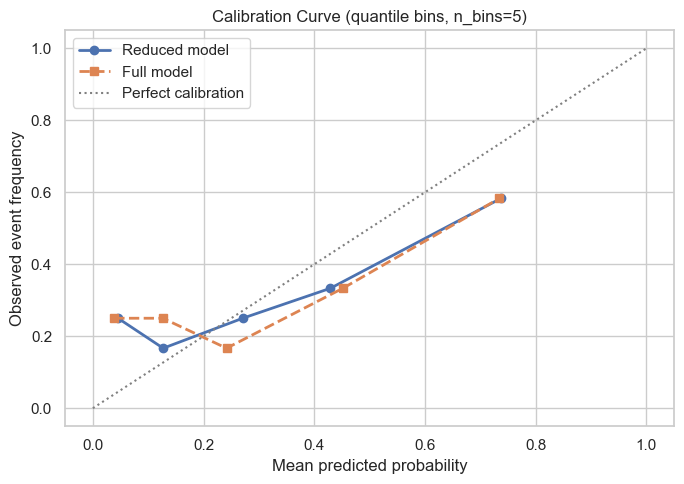

In [10]:
prob_true_r, prob_pred_r = calibration_curve(y_true_arr, y_prob_reduced, n_bins=5, strategy='quantile')
prob_true_f, prob_pred_f = calibration_curve(y_true_arr, y_prob_full,    n_bins=5, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred_r, prob_true_r, marker='o', linewidth=2,                 label='Reduced model')
ax.plot(prob_pred_f, prob_true_f, marker='s', linewidth=2, linestyle='--', label='Full model')
ax.plot([0, 1], [0, 1], linestyle=':', color='grey',                       label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed event frequency')
ax.set_title('Calibration Curve (quantile bins, n_bins=5)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
hl = hosmer_lemeshow_test(y_true_arr, y_prob_reduced, n_groups=10)

print('Hosmer-Lemeshow test — Reduced model')
print(f"  HL statistic       : {hl['hl_stat']:.4f}")
print(f"  Degrees of freedom : {hl['df']}")
print(f"  p-value            : {hl['p_value']:.4f}")
print()
conclusion = (
    'Fail to reject H0 — no significant evidence of miscalibration.'
    if hl['p_value'] > 0.05 else
    'Reject H0 — evidence of miscalibration detected.'
)
print(f'Conclusion: {conclusion}')
print()
print('Observed vs Expected per decile group:')
hl['groups']

Hosmer-Lemeshow test — Reduced model
  HL statistic       : 15.8100
  Degrees of freedom : 8
  p-value            : 0.0452

Conclusion: Reject H0 — evidence of miscalibration detected.

Observed vs Expected per decile group:


,group,n,observed,expected
0,0,6,1,0.1700
1,1,6,2,0.3753
2,2,6,1,0.6549
3,3,6,1,0.8696
4,4,6,2,1.3623
5,5,6,1,1.8866
6,6,6,1,2.2047
7,7,6,3,2.9466
8,8,6,3,3.7877
9,9,6,4,5.0627


### Inverted S-shaped calibration pattern

- Low-risk patients: the model predicts 7%, while the observed event rate is 25% (underestimation)

- High-risk patients: the model predicts 75%, while the observed event rate is 60% (overestimation)

This pattern represents the classical signature of a model that produces overly extreme probability estimates. The model pushes predictions toward the extremes more than the data support. In reality, the true risk distribution is more centered than the predicted probabilities.

## 7. Decision Curve Analysis

ROC-AUC and AUC-PR are statistical performance metrics. They do not directly answer
whether using the model leads to better clinical decisions than simpler alternatives.

**Decision Curve Analysis (DCA)** answers: at a given decision threshold (the probability
above which a clinician would intervene), does the model produce better outcomes than:
- **Treat all**: assume every patient is high-risk and intervene on everyone
- **Treat none**: assume no patient is high-risk and intervene on no one

**Net benefit at decision threshold t:**

    NB(t) = TP/n  -  FP/n * t/(1-t)

The weight t/(1-t) encodes the clinician's harm ratio: how many false positives are
acceptable to avoid one missed death. A clinician operating at t = 0.30 considers a
false positive 2.3x less harmful than a missed death.


In cardiology, the prevention of a single death can justify several unnecessary interventions; therefore, a ratio between 1:1 and 4:1 is considered clinically acceptable. The clinically plausible threshold range for this model lies approximately between 0.20 and 0.50, reflecting scenarios in which a false positive is one to four times less costly than a missed fatal event.

Within this relevant threshold range (0.20–0.50), the model demonstrates a net clinical benefit, outperforming both the “treat-all” and “treat-none” strategies. This finding is the key justification for its implementation in clinical practice.

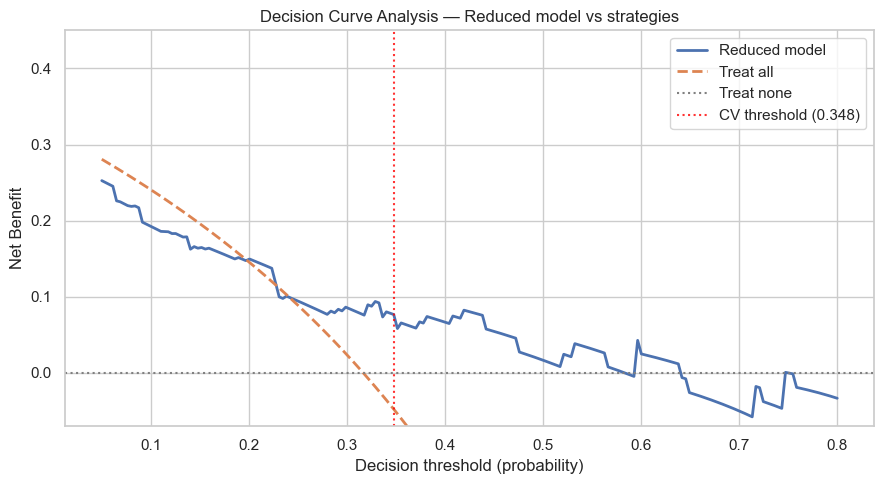

In [12]:
dca_df = compute_dca(y_true_arr, y_prob_reduced, thresholds=np.linspace(0.05, 0.80, 200))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dca_df['threshold'], dca_df['nb_model'], linewidth=2,                 label='Reduced model')
ax.plot(dca_df['threshold'], dca_df['nb_all'],   linewidth=2, linestyle='--', label='Treat all')
ax.axhline(0, color='grey',  linestyle=':',                                   label='Treat none')
ax.axvline(cv_threshold, color='red', linestyle=':', alpha=0.8,
           label=f'CV threshold ({cv_threshold:.3f})')
ax.set_xlabel('Decision threshold (probability)')
ax.set_ylabel('Net Benefit')
ax.set_title('Decision Curve Analysis — Reduced model vs strategies')
ax.set_ylim(-0.07, 0.45)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model Persistence

The fitted pipeline (preprocessing + model) is saved with `joblib`. This artifact encapsulates
the entire inference chain: the log1p transform, the StandardScaler parameters (fitted on the
training set), and the LogisticRegression weights.

To run inference on new patients:

```python
import joblib
import pandas as pd

pipeline = joblib.load('models/reduced_logit_pipeline.joblib')
X_new = pd.DataFrame([{
    'age': 65,
    'ejection_fraction': 30,
    'high_blood_pressure': 1,
    'serum_creatinine': 1.9
}])
p_death = pipeline.predict_proba(X_new)[0, 1]
```

Note: `X_new` must contain the raw (untransformed) feature values in the original units.
All transformations are applied inside the pipeline automatically.

In [13]:
models_dir = Path.cwd().parent / 'models'
models_dir.mkdir(exist_ok=True)

model_path = models_dir / 'reduced_logit_pipeline.joblib'
joblib.dump(reduced_pipeline, model_path)
print(f'Model saved to: {model_path}')

# Smoke test: reload and verify predictions are identical
loaded_pipeline  = joblib.load(model_path)
y_prob_reloaded  = loaded_pipeline.predict_proba(X_test[reduced_raw_vars])[:, 1]
assert np.allclose(y_prob_reduced, y_prob_reloaded), 'Prediction mismatch after reload'
print('Reload smoke test passed — predictions are identical.')

Model saved to: g:\Mi unidad\BrAIn\career\porfolio\Clinical-Risk-Prediction-for-Heart--Disease\models\reduced_logit_pipeline.joblib
Reload smoke test passed — predictions are identical.


## 9. Summary

### Model specification
| Component | Detail |
|-----|-----|
| Algorithm | Logistic regression (sklearn, L2, C=1.0) |
| Features | age, ejection_fraction, high_blood_pressure, serum_creatinine |
| Preprocessing | log1p + StandardScaler for serum_creatinine; StandardScaler for continuous; pass-through for binary |
| time | Excluded — data leakage |
| Threshold | CV-selected via Youden's J across 5 stratified folds |


### Limitations
- **External validation not possible**: single-centre dataset (Pakistan, 2015), n=299
- **Small test set**: CIs are wide; a single patient swings recall by ~5 percentage points
- **HL test underpowered** at n_test=60; calibration requires larger samples to assess formally
- **sklearn L2 regularisation**: introduces slight coefficient shrinkage relative to 03_logistic_regression_model statsmodels ORs